# 파일 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
weather = pd.read_csv(
    "hanwoo_weather.csv")

train = pd.read_csv(
    "hanwoo_train.csv")

lineage = pd.read_csv(
    "hanwoo_lineage.csv")

area = pd.read_csv(
    "hanwoo_area.csv")

death = pd.read_csv(
    "hanwoo_death.csv")

In [5]:
print(weather.columns)
print(train.columns)
print(lineage.columns)
print(area.columns)
print(death.columns)

Index(['stn', 'date', 'ta_max', 'rn_day', 'ta_min', 'rhm_avg', 'ws_davg'], dtype='object')
Index(['sido', 'sigungu', 'eupmyeondong', 'stn', 'ABATT_DATE', 'JUDGE_DATE',
       'JUDGE_SEX', 'WEIGHT', 'BACKFAT', 'REA', 'WINDEX', 'WGRADE', 'INSFAT',
       'YUKSAK', 'FATSAK', 'TISSUE', 'GROWTH', 'COST_AMT', 'AGE', 'BIRTH_YMD',
       'CATTLE_NO', 'FARM_UNIQUE_NO', 'LAST_GRADE'],
      dtype='object')
Index(['CATTLE_NO', 'KPN_NO', 'FATHER_CATTLE_NO', 'MOTHER_ANIMAL_NO',
       'F_GMOTHER_ANIMAL_NO', 'F_GFATHER_CATTLE_NO', 'M_GMOTHER_ANIMAL_NO',
       'M_GFATHER_CATTLE_NO'],
      dtype='object')
Index(['FARM_UNIQUE_NO', 'C2023', 'C2024', 'C2025', 'AREA'], dtype='object')
Index(['FARM_UNIQUE_NO', 'BIRTH_YMD', 'DEAD_YMD', 'DEAD_REASON'], dtype='object')


# 결측치 확인

In [7]:
datasets = {
    "weather": weather, 
    "train": train, 
    "lineage": lineage, 
    "area": area, 
    "death": death
}

for name, df in datasets.items(): # 결측치 확인용

    summary = pd.DataFrame({
        "missing_count": df.isnull().sum(),
        "minus99_count": (df == -99).sum()
    })

    print(f"\n================ {name} ================")
    print(f"행: {df.shape[0]}, 열: {df.shape[1]}")
    print(summary)


================ weather ================
행: 973248, 열: 7
         missing_count  minus99_count
stn                  0              0
date                 0              0
ta_max               0          12364
rn_day               0          15993
ta_min               0          12364
rhm_avg              0          48155
ws_davg              0          13602

================ train ================
행: 2408699, 열: 23
                missing_count  minus99_count
sido                        0              0
sigungu                     0              0
eupmyeondong                0              0
stn                         0              0
ABATT_DATE                  0              0
JUDGE_DATE                  0              0
JUDGE_SEX                   0              0
WEIGHT                      0              0
BACKFAT                     0           4567
REA                         0           5188
WINDEX                      0           5252
WGRADE                      0         

In [124]:
print((lineage == -99).sum()) # lineage는 문자형 데이터라 -99를 NaN 처리 해야할 듯, 중요한 변수는 아님
print((lineage == "-99").sum())

CATTLE_NO              0
KPN_NO                 0
FATHER_CATTLE_NO       0
MOTHER_ANIMAL_NO       0
F_GMOTHER_ANIMAL_NO    0
F_GFATHER_CATTLE_NO    0
M_GMOTHER_ANIMAL_NO    0
M_GFATHER_CATTLE_NO    0
dtype: int64
CATTLE_NO                 0
KPN_NO                 4490
FATHER_CATTLE_NO          0
MOTHER_ANIMAL_NO          0
F_GMOTHER_ANIMAL_NO       0
F_GFATHER_CATTLE_NO       0
M_GMOTHER_ANIMAL_NO       0
M_GFATHER_CATTLE_NO       0
dtype: int64


# train 데이터와 weather 데이터를 연결(merge)

In [125]:
df = pd.merge( # train과 weather를 merge
    train,
    weather,
    left_on=["stn", "JUDGE_DATE"],
    right_on=["stn", "date"],
    how="left"
)

In [126]:
df.shape # 결과 확인, stn 컬럼은 weather와 train 데이터 모두 있어서 총 컬럼은 30개가 아닌 29개

(2408699, 29)

In [127]:
df.head() # train 쪽 : 지역, 성별 체중, 등급, 개체 정보
# weather 쪽, 최고기온, 최저기온, 강수량, 습도, 풍속

,sido,sigungu,eupmyeondong,stn,ABATT_DATE,JUDGE_DATE,JUDGE_SEX,WEIGHT,BACKFAT,REA,...,BIRTH_YMD,CATTLE_NO,FARM_UNIQUE_NO,LAST_GRADE,date,ta_max,rn_day,ta_min,rhm_avg,ws_davg
0,강원특별자치도,정선군,북평면,563,2023-01-01,2023-01-02,암,218,3.0,44.0,...,20160915,mI4i8G0BJ8kWD6gdm77RmTzyuIx6N2ZMaZ7wFXx3xb4=,hqh4Qmh5g+ymbYtqjAeKeA==,3B,2023-01-02,1.4,0.0,-12.2,49.0,1.8
1,강원특별자치도,평창군,진부면,560,2023-01-01,2023-01-02,거세,520,12.0,100.0,...,20200504,tMgfi1p35taO9GH4XN4x0bfO8czy79B8V9NyczRuV+8=,N5qW6dZ91QWCMHg/1kPdlA==,1B,2023-01-02,-0.1,0.0,-15.7,53.0,2.0
2,경상북도,영주시,이산면,837,2023-01-01,2023-01-02,거세,452,14.0,104.0,...,20200803,mdsSD4/sB06U68LNT6P/GUwei2ISyIBZ+R04iLw2mX0=,5UbtU8TgV2yu3Y4/jxuNMQ==,1++B,2023-01-02,3.6,0.0,-10.9,53.0,0.5
3,강원특별자치도,평창군,진부면,560,2023-01-01,2023-01-02,거세,454,12.0,95.0,...,20200510,LZWd4YatUD851LyC/LFXuxPW7KEXTwVWQONOwqrkLPI=,N5qW6dZ91QWCMHg/1kPdlA==,1++B,2023-01-02,-0.1,0.0,-15.7,53.0,2.0
4,강원특별자치도,평창군,진부면,560,2023-01-01,2023-01-02,거세,462,10.0,78.0,...,20200511,A4FF/dhr8vg7JeW/eqc3922pA69nEaLL/+uoAusZqyU=,N5qW6dZ91QWCMHg/1kPdlA==,1B,2023-01-02,-0.1,0.0,-15.7,53.0,2.0


In [128]:
df.isnull().sum()

sido              0
sigungu           0
eupmyeondong      0
stn               0
ABATT_DATE        0
JUDGE_DATE        0
JUDGE_SEX         0
WEIGHT            0
BACKFAT           0
REA               0
WINDEX            0
WGRADE            0
INSFAT            0
YUKSAK            0
FATSAK            0
TISSUE            0
GROWTH            0
COST_AMT          0
AGE               0
BIRTH_YMD         0
CATTLE_NO         0
FARM_UNIQUE_NO    0
LAST_GRADE        0
date              0
ta_max            0
rn_day            0
ta_min            0
rhm_avg           0
ws_davg           0
dtype: int64

### 결측치 처리

In [ ]:
# train 데이터와 weather 데이터를 연결(merge) 후 가장 먼저 할 일!
df = pd.merge(train, weather, left_on=["stn", "JUDGE_DATE"], right_on=["stn", "date"], how="left")

# 1. -99 결측치 우선 처리
df = df.replace([-99, "-99", -99.0], np.nan) 

# 2. 파생변수 생성
df["temp_avg"] = (df["ta_max"] + df["ta_min"]) / 2
df["temp_gap"] = df["ta_max"] - df["ta_min"]
df["heatwave"] = (df["ta_max"] >= 33).astype(int) 
df["coldwave"] = (df["ta_min"] <= -10).astype(int)

# 파생변수

In [129]:
df["temp_avg"] = ( # 평균기온
    df["ta_max"] +
    df["ta_min"]
) / 2

In [130]:
df["temp_gap"] = ( # 일교차
    df["ta_max"] -
    df["ta_min"]
)

In [131]:
df["heatwave"] = ( # 폭염 여부
    df["ta_max"] >= 33
).astype(int) 

In [132]:
df["coldwave"] = ( # 한파 여부
    df["ta_min"] <= -10
).astype(int)

# 종속변수 (Y) 선택

In [133]:
# WGRADE 고유값 확인 # 육량등급(A/B/C)
print(df["WGRADE"].unique())

# LAST_GRADE 고유값 확인 # 육질등급(1++, 1+, 1, 2, 3)
print(df["LAST_GRADE"].unique())

['A' 'B' 'C' 'D' '-99.0']
['3B' '1B' '1++B' '1+B' '2B' '2A' '1++A' '1+C' '1+A' '3A' '2C' '1++C' '1A'
 '3C' '1C' '등외']


In [134]:
print(df["WGRADE"].value_counts()) # 결측치 5363개 존재(-99.0)

print(df["LAST_GRADE"].value_counts()) # 결측치 거의 안 보임 # LAST_GRADE를 Y로 사용

WGRADE
B        1146958
A         799635
C         456854
-99.0       4814
D            438
Name: count, dtype: int64
LAST_GRADE
1++B    319588
1+B     311222
1B      299290
1++A    207026
2B      195866
1A      168174
1+A     167246
1+C     130094
1++C    128997
2A      127410
1C      116976
3B       97576
2C       62938
3A       47214
3C       23542
등외        5540
Name: count, dtype: int64


# 육질등급별 주요 변수 평균 비교

In [135]:
# 육질등급별 체중
df.groupby("LAST_GRADE")["WEIGHT"].mean()

LAST_GRADE
1++A    449.211481
1++B    470.391154
1++C    486.880734
1+A     418.680817
1+B     442.090594
1+C     463.211793
1A      396.213850
1B      416.367707
1C      441.456068
2A      369.239471
2B      374.662616
2C      407.616337
3A      347.670818
3B      308.381385
3C      336.052842
등외      159.356137
Name: WEIGHT, dtype: float64

In [136]:
# 육질등급별 평균기온
df.groupby("LAST_GRADE")["temp_avg"].mean()

LAST_GRADE
1++A    14.139559
1++B    13.535199
1++C    12.746252
1+A     14.197447
1+B     13.789336
1+C     13.217237
1A      14.216636
1B      14.033011
1C      13.475581
2A      13.992306
2B      14.192351
2C      13.711167
3A      14.013950
3B      14.331437
3C      14.152294
등외      13.593736
Name: temp_avg, dtype: float64

In [137]:
# 육질등급별 등지방두께(BACKFAT)
df.groupby("LAST_GRADE")["BACKFAT"].mean()

LAST_GRADE
1++A     8.871987
1++B    13.529047
1++C    20.979759
1+A      8.269806
1+B     12.774788
1+C     20.334850
1A       7.933051
1B      12.330135
1C      20.166179
2A       7.551307
2B      11.444084
2C      20.266580
3A       6.984687
3B       8.903152
3C      18.394996
등외     -81.253791
Name: BACKFAT, dtype: float64

In [138]:
# 등심단면적(REA)
df.groupby("LAST_GRADE")["REA"].mean()

LAST_GRADE
1++A    108.090955
1++B    101.876460
1++C     98.962573
1+A      98.485877
1+B      93.963920
1+C      91.900464
1A       93.755450
1B       89.089562
1C       87.868879
2A       89.346048
2B       82.898083
2C       83.562284
3A       86.678951
3B       72.522126
3C       71.393000
등외      -90.125993
Name: REA, dtype: float64

In [139]:
# 육량지수(WINDEX) 중요
df.groupby("LAST_GRADE")["WINDEX"].mean()

LAST_GRADE
1++A    63.357220
1++B    61.440644
1++C    59.268644
1+A     63.178073
1+B     61.307416
1+C     59.060342
1A      63.114222
1B      61.244764
1C      58.890686
2A      63.126139
2B      61.418018
2C      58.681227
3A      63.655013
3B      62.582237
3C      58.980783
등외     -90.452208
Name: WINDEX, dtype: float64

In [140]:
# 나이
df.groupby("LAST_GRADE")["AGE"].mean()

LAST_GRADE
1++A    33.365176
1++B    34.056047
1++C    34.633472
1+A     36.661325
1+B     37.356498
1+C     38.805072
1A      40.421712
1B      41.326392
1C      43.838180
2A      47.208696
2B      49.600349
2C      56.421717
3A      75.568306
3B      80.436798
3C      91.117874
등외      62.710650
Name: AGE, dtype: float64

# 기상 변수 비교

In [141]:
# 육질등급별 평균 강수량
df.groupby("LAST_GRADE")["rn_day"].mean()

LAST_GRADE
1++A    3.614102
1++B    3.474022
1++C    3.293700
1+A     3.704364
1+B     3.652680
1+C     3.472126
1A      3.736730
1B      3.717583
1C      3.630609
2A      3.772618
2B      3.905102
2C      3.715024
3A      3.797367
3B      4.003481
3C      4.447800
등외      3.682690
Name: rn_day, dtype: float64

In [142]:
# 육질등급별 평균 풍속
df.groupby("LAST_GRADE")["ws_davg"].mean()

LAST_GRADE
1++A    0.130918
1++B    0.185723
1++C    0.169419
1+A     0.148637
1+B     0.096621
1+C     0.082298
1A      0.078848
1B      0.069693
1C      0.059865
2A      0.044636
2B     -0.018766
2C     -0.061151
3A      0.019905
3B      0.059017
3C      0.211401
등외     -0.905758
Name: ws_davg, dtype: float64

In [143]:
# 육질등급별 일교차
df.groupby("LAST_GRADE")["temp_gap"].mean()

LAST_GRADE
1++A    10.983264
1++B    11.017153
1++C    11.137791
1+A     10.992511
1+B     11.013669
1+C     11.099018
1A      11.004238
1B      10.973596
1C      11.034114
2A      10.965310
2B      10.938908
2C      11.039070
3A      10.984041
3B      10.952007
3C      10.962637
등외      11.052455
Name: temp_gap, dtype: float64

# 시각화

c:\Users\pc\miniconda3\envs\img2_2025\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46321 (\N{HANGUL SYLLABLE DEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\pc\miniconda3\envs\img2_2025\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50808 (\N{HANGUL SYLLABLE OE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


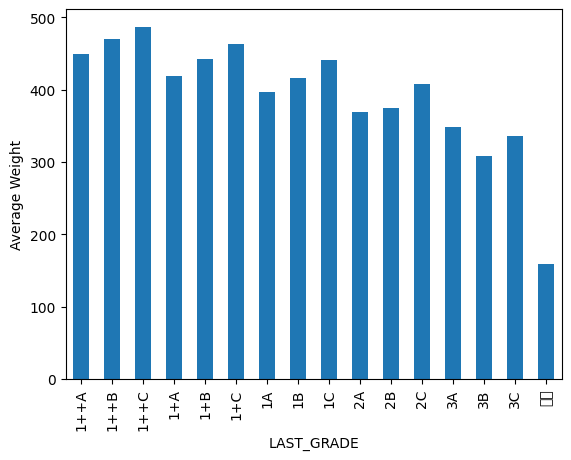

In [144]:
# 육질등급별 체중 그래프
import matplotlib.pyplot as plt

df.groupby("LAST_GRADE")["WEIGHT"].mean().plot(
    kind="bar"
)

plt.xlabel("LAST_GRADE")
plt.ylabel("Average Weight")

plt.show()

c:\Users\pc\miniconda3\envs\img2_2025\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46321 (\N{HANGUL SYLLABLE DEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\pc\miniconda3\envs\img2_2025\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50808 (\N{HANGUL SYLLABLE OE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


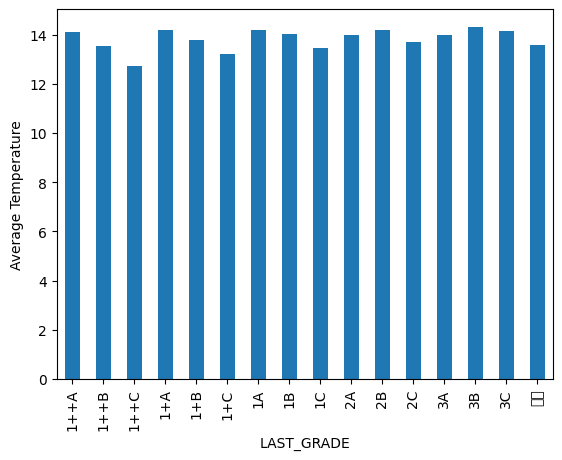

In [145]:
# 육질등급별 평균기온 그래프
df.groupby("LAST_GRADE")["temp_avg"].mean().plot(
    kind="bar"
)

plt.xlabel("LAST_GRADE")
plt.ylabel("Average Temperature")

plt.show()

# 상관관계 분석

In [146]:
numeric_cols = [
    "WEIGHT",
    "BACKFAT",
    "REA",
    "WINDEX",
    "AGE",
    "temp_avg",
    "temp_gap",
    "rn_day",
    "ws_davg"
]

corr_matrix = df[numeric_cols].corr()

print(corr_matrix)

            WEIGHT   BACKFAT       REA    WINDEX       AGE  temp_avg  \
WEIGHT    1.000000  0.298566  0.671375  0.103502 -0.403679 -0.035033   
BACKFAT   0.298566  1.000000  0.428091  0.459070 -0.007971 -0.025119   
REA       0.671375  0.428091  1.000000  0.522593 -0.261047 -0.025324   
WINDEX    0.103502  0.459070  0.522593  1.000000 -0.069172  0.005698   
AGE      -0.403679 -0.007971 -0.261047 -0.069172  1.000000  0.019092   
temp_avg -0.035033 -0.025119 -0.025324  0.005698  0.019092  1.000000   
temp_gap  0.021515  0.009924  0.020578 -0.001679 -0.002686 -0.042071   
rn_day   -0.015715 -0.004134 -0.010847  0.000267  0.009483  0.319285   
ws_davg   0.008951  0.001840  0.009750  0.004259  0.001248  0.182990   

          temp_gap    rn_day   ws_davg  
WEIGHT    0.021515 -0.015715  0.008951  
BACKFAT   0.009924 -0.004134  0.001840  
REA       0.020578 -0.010847  0.009750  
WINDEX   -0.001679  0.000267  0.004259  
AGE      -0.002686  0.009483  0.001248  
temp_avg -0.042071  0.319285  0.1

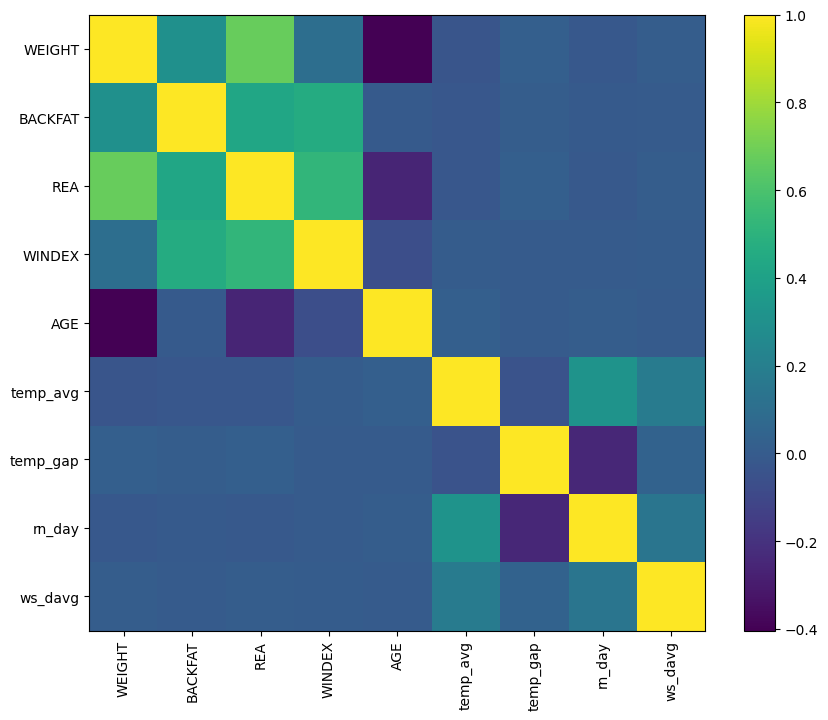

In [147]:
# 히트맵 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.imshow(corr_matrix)

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.show()

# 폭염 영향 분석 (최고 기온이 33도 이상이면 1, 아니면 0으로 설정)

In [148]:
# 폭염 여부별 평균 체중
df.groupby("heatwave")["WEIGHT"].mean()

heatwave
0    422.922237
1    420.857144
Name: WEIGHT, dtype: float64

In [149]:
# 폭염 여부별 평균 육량지수
df.groupby("heatwave")["WINDEX"].mean()

heatwave
0    61.149314
1    61.326359
Name: WINDEX, dtype: float64

In [150]:
# 폭염 여부별 평균 등급 분포
pd.crosstab(
    df["heatwave"],
    df["LAST_GRADE"]
)

LAST_GRADE,1++A,1++B,1++C,1+A,1+B,1+C,1A,1B,1C,2A,2B,2C,3A,3B,3C,등외
heatwave,,,,,,,,,,,,,,,,
0,188139,293439,119650,152247,285300,120189,153213,273983,107941,116529,179509,58072,43381,89538,21799,5191
1,18887,26149,9347,14999,25922,9905,14961,25307,9035,10881,16357,4866,3833,8038,1743,349


# 산점도

In [151]:
# -99를 NaN 처리
df = df.replace(-99, np.nan) # 숫자형
df = df.replace("-99", np.nan) # 문자형

In [152]:
# 파생변수 재생성 (평균기온)
df["temp_avg"] = (
    df["ta_max"] +
    df["ta_min"]
) / 2

In [153]:
# 일교차
df["temp_gap"] = (
    df["ta_max"] -
    df["ta_min"]
)

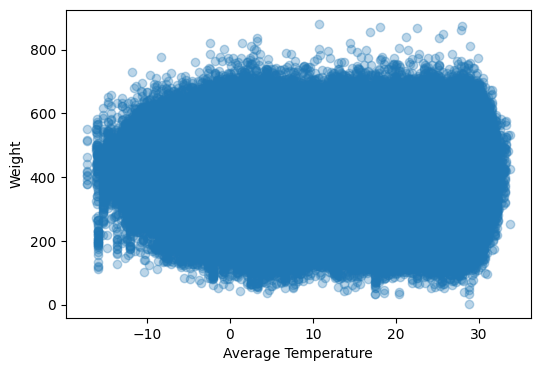

In [154]:
# 체중 vs 평균기온
plt.figure(figsize=(6, 4))

plt.scatter(
    df["temp_avg"],
    df["WEIGHT"],
    alpha=0.3
)

plt.xlabel("Average Temperature")
plt.ylabel("Weight")

plt.show()

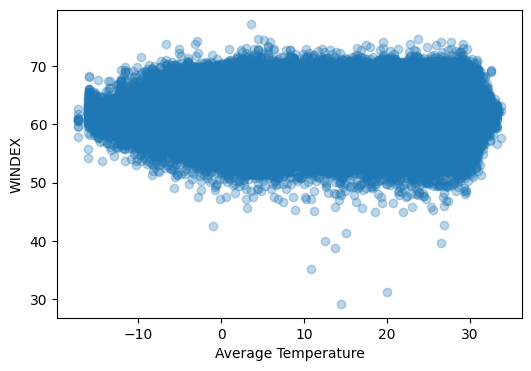

In [155]:
# 육량지수 vs 평균기온
plt.figure(figsize=(6, 4))

plt.scatter(
    df["temp_avg"], 
    df["WINDEX"],
    alpha=0.3
)

plt.xlabel("Average Temperature")
plt.ylabel("WINDEX")

plt.show()

# 지역별 분석

In [156]:
# 시도별 평균 체중
df.groupby("sido")["WEIGHT"].mean().sort_values()

sido
서울특별시      335.295455
부산광역시      395.342541
대전광역시      402.909762
충청남도       410.571292
충청북도       412.708575
울산광역시      412.748769
광주광역시      413.704800
전라남도       415.939708
강원특별자치도    418.247082
세종특별자치시    418.261026
경상남도       421.340968
제주특별자치도    421.934029
전북특별자치도    422.857079
경기도        423.573548
대구광역시      433.944660
경상북도       436.440880
인천광역시      448.128958
Name: WEIGHT, dtype: float64

In [157]:
# 시도별 평균 육량지수
df.groupby("sido")["WINDEX"].mean().sort_values()

sido
전라남도       61.313195
울산광역시      61.373058
경상북도       61.445429
세종특별자치시    61.446458
대구광역시      61.474842
부산광역시      61.487459
충청남도       61.532413
경상남도       61.542866
충청북도       61.567179
전북특별자치도    61.584645
광주광역시      61.632313
대전광역시      61.672224
제주특별자치도    61.678388
강원특별자치도    61.686607
경기도        61.751460
인천광역시      62.025190
서울특별시      63.486591
Name: WINDEX, dtype: float64

# 계절 변수

In [158]:
# 날짜형 변환
df["JUDGE_DATE"] = pd.to_datetime(
    df["JUDGE_DATE"]
)

In [159]:
# 월 추출
df["month"] = df["JUDGE_DATE"].dt.month

In [160]:
# 계절 생성
def get_season(month):

    if month in [3, 4, 5]:
        return "spring"

    elif month in [6, 7, 8]:
        return "summer"

    elif month in [9, 10, 11]:
        return "fall"

    else:
        return "winter"

df["season"] = df["month"].apply(get_season)

In [161]:
# 확인 코드
df[["JUDGE_DATE", "month", "season"]].head()

,JUDGE_DATE,month,season
0,2023-01-02,1,winter
1,2023-01-02,1,winter
2,2023-01-02,1,winter
3,2023-01-02,1,winter
4,2023-01-02,1,winter


In [162]:
# 계절별 평균 체중
df.groupby("season")["WEIGHT"].mean()

season
fall      422.770592
spring    422.610294
summer    418.227768
winter    427.105876
Name: WEIGHT, dtype: float64

In [163]:
# 계절별 평균 육량지수
df.groupby("season")["WINDEX"].mean()

season
fall      61.580776
spring    61.468398
summer    61.554847
winter    61.452055
Name: WINDEX, dtype: float64

In [164]:
# 계절별 평균 기온
df.groupby("season")["temp_avg"].mean()

season
fall      17.056645
spring    13.417437
summer    25.916249
winter     1.281728
Name: temp_avg, dtype: float64

# area 데이터 연결(train + weather 데이터에 area도 merge)
# 추가로 해야할 듯한 부분

In [165]:
df = pd.merge( # area는 농가 규모
    df,
    area,
    on="FARM_UNIQUE_NO",
    how="left"
)

In [166]:
df[["FARM_UNIQUE_NO", "C2025", "AREA"]].head()

,FARM_UNIQUE_NO,C2025,AREA
0,hqh4Qmh5g+ymbYtqjAeKeA==,6.0,95.00
1,N5qW6dZ91QWCMHg/1kPdlA==,NaN,NaN
2,5UbtU8TgV2yu3Y4/jxuNMQ==,89.0,977.28
3,5UbtU8TgV2yu3Y4/jxuNMQ==,96.0,977.28
4,N5qW6dZ91QWCMHg/1kPdlA==,NaN,NaN


In [167]:
# 사육밀도 생성 # 밀도 면적에 따른 소 마리수 체크
df["density"] = ( 
    df["C2025"] / df["AREA"] 
)

In [168]:
df["density"].isnull().sum()

np.int64(37384)

In [ ]:
# 결측치(NaN) 제외한 데이터만 따로 사용
density_df = df.dropna( 
    subset=["density"]
)

In [170]:
density_df.groupby(
    "LAST_GRADE"
)["density"].mean()

LAST_GRADE
1++A         inf
1++B         inf
1++C        -inf
1+A    -0.403930
1+B          NaN
1+C          inf
1A     -0.354085
1B          -inf
1C           NaN
2A           inf
2B           inf
2C           NaN
3A     -0.276645
3B     -0.420805
3C           inf
등외     -0.981138
Name: density, dtype: float64

In [171]:
density_df["density"].describe()

c:\Users\pc\miniconda3\envs\img2_2025\Lib\site-packages\numpy\_core\_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


count    2.654599e+06
mean              NaN
std               NaN
min              -inf
25%     -3.333333e-01
50%      3.591381e-02
75%      8.000000e-02
max               inf
Name: density, dtype: float64